In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
print("a")

a


In [1]:
!pip install datasets transformers

In [2]:
import transformers

print(transformers.__version__)

5.0.0


###  Load Data

In [3]:
from datasets import load_dataset
datasets = load_dataset('wikitext', 'wikitext-2-raw-v1')

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [4]:
datasets["train"][10]

{'text': ' The game \'s battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . During missions , players select each unit using a top @-@ down perspective of the battlefield map : once a character is selected , the player moves the character around the battlefield in third @-@ person . A character can only act once per @-@ turn , but characters can be granted multiple turns at the expense of other characters \' turns . Each character has a field and distance of movement limited by their Action Gauge . Up to nine characters can be assigned to a single mission . During gameplay , characters will call out if something happens to them , such as their health points ( HP ) getting low or being knocked out by enemy attacks . Each character has specific " Potentials " , skills unique to each character . They are divided into " Personal Potential " , which are innate skills that remain unaltered unless otherwise dictated by the story and can either help or impede

In [5]:
column = datasets["train"].features.items()
column

dict_items([('text', Value('string'))])

In [8]:
from datasets import ClassLabel
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)
    
    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
    display(HTML(df.to_html()))

In [9]:
show_random_elements(datasets["train"])

,text
0,"The median age in Sarnia is 44 @.@ 5 which is older than the Canadian median of 40 @.@ 95 , indicative of Sarnia 's aging population . According to the 2011 Census , Sarnia is predominately Christian as 28 @.@ 46 % of the population were Catholic , 12 @.@ 4 % were members of the United Church of Canada , 7 @.@ 3 % were Anglican , and 20 @.@ 06 % were of other Christian faiths , Muslim , or Jewish ; 28 @.@ 38 % professed no religious preference or were atheists . The median income counting all persons 15 years old or older in Sarnia in 2010 was $ 29 @,@ 196 , while median family income was $ 76 @,@ 523 , both of which were slightly lower than Ontario 's , at $ 30 @,@ 526 and $ 80 @,@ 987 , respectively . The cost of living in Sarnia , however , is significantly lower than it is in Ontario as a whole . The median value of a dwelling , for instance , is $ 179 @,@ 266 , compared to the $ 300 @,@ 862 of Ontario as a whole . \n"
1,
2,= = Themes = = \n
3,Jumping tornado DDT \n
4,= = = = Start of FRELIMO attacks = = = = \n
5,
6,"Masturbation is considered sinful for the same reasons as lust , but is a step above lust in that it involves a physical act instead of a mental one . \n"
7,
8,"Meyerbeer 's large choral ' tableaux ' also made a major contribution to the overall dramatic effect ; the composer particularly sought opportunities to write such large @-@ scale crowd scenes , and preferred libretti which offered such possibilities . Crosten writes : ' These massive developed sections are the chief glory of the Meyerbeerian opera , for they are not only big in volume but big in their structural design ' . \n"
9,"During the day the Fusiliers again assaulted Hill 217 from the south , and attempted to work their way around the eastern and western flanks of the feature . Despite preparation by the divisional artillery and the 3 RAR Machine Gun Platoon firing their Vickers medium machine @-@ guns in support from Maryang San , the Fusiliers were unable to make progress due to Chinese machine @-@ guns located in bunkers at the top of their objective . Meanwhile , their flanking movements were also blocked by Chinese small arms and grenades . 1 RNF had now taken over 100 casualties during two days of fighting and by the afternoon they were a spent force . Sensing the Fusiliers ' weakness , the Chinese then launched their own assault , forcing them to withdraw in contact . Previous plans for an assault on the Hinge had not occurred due to issues with resupply and the dangerous approach march that would have been required . Again , despite their efforts , the Fusiliers had failed to capture their objective . It seemed that the only way to finally secure Hill 217 was along the ridge from Hill 317 , via the Hinge , and as such the Australians would be tasked with capturing the Hinge the following day . B Company was subsequently allocated the attack . In preparation , they ascended Hill 317 late in the afternoon of 6 October , finally securing the crest , and at last light joined 9 Platoon on the knoll northwest of the summit where they would form up the next day to conduct the assault . \n"


## Casual language modeling(CLM)

In [6]:
model_checkpoint = "distilgpt2"

In [7]:
from transformers import AutoTokenizer
    
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
def tokenize_function(examples):
    return tokenizer(examples["text"])

In [9]:
tokenized_datasets = datasets.map(tokenize_function, batched=True, num_proc=4, )

Map (num_proc=4):   0%|          | 0/4358 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/36718 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/3760 [00:00<?, ? examples/s]

In [10]:
tokenized_datasets = tokenized_datasets.map(remove_columns=["text"])

Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [11]:
tokenized_datasets["train"][1]

{'input_ids': [796, 569, 18354, 7496, 17740, 6711, 796, 220, 198],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [12]:
block_size = 128

In [13]:
def group_texts(examples):
    # Concatenate all texts.
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])
    # We drop the small remainder, we could add padding if the model supported it instead of this drop, you can
        # customize this part to your needs.
    total_length = (total_length // block_size) * block_size
    # Split by chunks of max_len.
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result


In [14]:
lm_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    batch_size=1000,
    num_proc=4,
)


Map (num_proc=4):   0%|          | 0/4358 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/36718 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/3760 [00:00<?, ? examples/s]

In [15]:
print(lm_datasets["train"][1])

{'input_ids': [983, 290, 5679, 262, 366, 17871, 5321, 366, 837, 257, 23634, 2422, 4326, 7351, 262, 3277, 286, 7096, 544, 1141, 262, 5498, 1898, 6839, 1810, 508, 1620, 3200, 2042, 4560, 290, 389, 46852, 1028, 262, 11773, 4326, 366, 2199, 321, 265, 88, 12552, 366, 764, 220, 198, 383, 983, 2540, 2478, 287, 3050, 837, 6872, 625, 257, 1588, 6903, 286, 262, 670, 1760, 319, 569, 18354, 7496, 17740, 2873, 764, 2893, 340, 17383, 262, 3210, 3033, 286, 262, 2168, 837, 340, 635, 25289, 3294, 16895, 837, 884, 355, 1642, 262, 983, 517, 43486, 329, 2168, 29661, 764, 15684, 11915, 371, 4548, 64, 8835, 73, 280, 290, 26777, 7286, 13704, 13231, 43354, 1111, 4504, 422, 2180, 12784, 837, 1863, 351, 569, 18354, 7496, 17740, 2873, 3437, 33687, 5303, 18024], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [16]:
tokenizer.decode(lm_datasets["train"][1]["input_ids"])

' game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Character designer Raita Honjou and composer Hitoshi Sakimoto both returned from previous entries , along with Valkyria Chronicles II director Takeshi Oz'

In [17]:
from transformers import AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained(model_checkpoint)

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [21]:
from transformers import Trainer, TrainingArguments

In [22]:
model_name = model_checkpoint.split("/")[-1]
training_args = TrainingArguments(
    f"{model_name}-finetuned-wikitext2",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
)


In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_datasets["train"],
    eval_dataset=lm_datasets["validation"],
)


In [24]:
trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.769931,3.651970
2,3.660245,3.630231
3,3.619910,3.624775


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3501, training_loss=3.7061944265292053, metrics={'train_runtime': 1011.0204, 'train_samples_per_second': 55.388, 'train_steps_per_second': 3.463, 'total_flos': 1829011929956352.0, 'train_loss': 3.7061944265292053, 'epoch': 3.0})

In [26]:
import math
eval_results = trainer.evaluate()
print(f"Perplexity: {math.exp(eval_results['eval_loss']):.2f}")


In [25]:
trainer.evaluate()

{'eval_loss': 3.624774932861328,
 'eval_runtime': 12.0912,
 'eval_samples_per_second': 159.703,
 'eval_steps_per_second': 10.007,
 'epoch': 3.0}

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.920565,3.689750,0.000017,0.428449,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.769931,3.706602,0.000014,0.856898,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.000000,1167,3.65197,12.0515,160.229,10.04,NaN,NaN,NaN,NaN,NaN
3,3.704397,4.397313,0.000011,1.285347,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.660245,3.775286,0.000009,1.713796,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


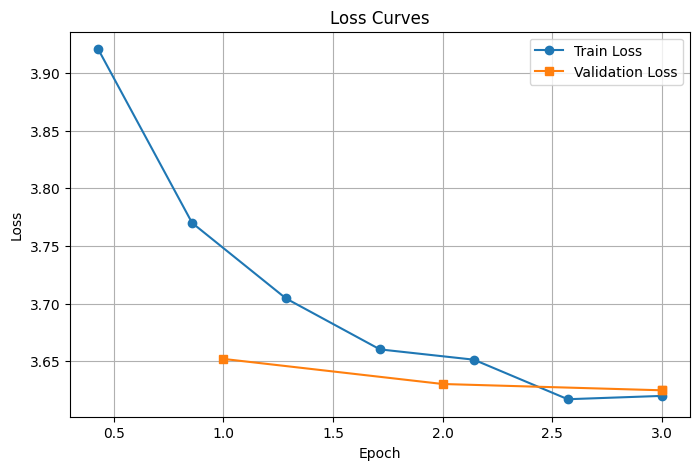

In [27]:
plt.figure(figsize=(8,5))

train_logs = history.dropna(subset=["loss"])
eval_logs = history.dropna(subset=["eval_loss"])

plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

### inference

In [28]:
trainer.model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [29]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=trainer.model,
    tokenizer=tokenizer
)

output = generator("Once upon a time")

print(output[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time of death, she was given the name " Yolanda ", and her mother, Eva, was buried in the courtyard of the family's former home. In the early 1990s, she moved to New York City, where she graduated with a degree in English from the University of Pennsylvania. She moved to New York City to study English at her native Spanish @-@ speaking Spanish school, and spent the summer of 2003 studying Spanish at the University of Chicago. 
 = = = Adoration = = = 
 On August 27, 2003, she was crowned the first Asian American woman to be elected National Vice President of the United States. According to her biography, " Yolanda was born in the village of Nellipus, New York. She was born in her mother's village of Nellipus, New York, where she was born and raised. She was raised in Nellipus, New York, but moved to New York City. She attended a school in nearby Brooklyn, the borough of New York City, where she received her first American citizenship. She attended the University of Pennsylva

## MLM

In [29]:
model_checkpoint = "distilroberta-base"

In [30]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)
tokenized_datasets = datasets.map(tokenize_function, batched=True, num_proc=4, remove_columns=["text"])

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map (num_proc=4):   0%|          | 0/4358 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (544 > 512). Running this sequence through the model will result in indexing errors


Map (num_proc=4):   0%|          | 0/36718 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (560 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (528 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (638 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (522 > 512). Running this sequence through the model will result in indexing errors


Map (num_proc=4):   0%|          | 0/3760 [00:00<?, ? examples/s]

In [31]:
lm_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    batch_size=1000,
    num_proc=4,
)

Map (num_proc=4):   0%|          | 0/4358 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/36718 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/3760 [00:00<?, ? examples/s]

In [32]:
lm_datasets["train"][1]

{'input_ids': [5,
  527,
  1237,
  12980,
  7,
  5,
  78,
  177,
  8,
  3905,
  5,
  22,
  8603,
  13802,
  22,
  2156,
  10,
  14914,
  831,
  1933,
  2754,
  5,
  1226,
  9,
  7155,
  493,
  148,
  5,
  4665,
  5122,
  12560,
  1771,
  54,
  3008,
  3556,
  909,
  1414,
  8,
  32,
  30259,
  136,
  5,
  16659,
  1933,
  22,
  2912,
  424,
  415,
  219,
  22546,
  22,
  479,
  1437,
  50118,
  2,
  0,
  20,
  177,
  880,
  709,
  11,
  1824,
  2156,
  3406,
  81,
  10,
  739,
  4745,
  9,
  5,
  173,
  626,
  15,
  468,
  44068,
  6374,
  41674,
  3082,
  479,
  616,
  24,
  12544,
  5,
  2526,
  1575,
  9,
  5,
  651,
  2156,
  24,
  67,
  12796,
  1533,
  11431,
  2156,
  215,
  25,
  442,
  5,
  177,
  55,
  36341,
  13,
  651,
  19298,
  479,
  35177,
  6004,
  248,
  5236,
  102,
  8768,
  267,
  1438,
  8,
  17964,
  15225,
  23552,
  17040,
  36066,
  258,
  1835,
  31,
  986,
  11410,
  2156,
  552,
  19],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1

In [33]:
from transformers import AutoModelForMaskedLM
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:


model_name = model_checkpoint.split("/")[-1]
training_args = TrainingArguments(
    f"{model_name}-finetuned-wikitext2",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
)



In [35]:
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)


In [36]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_datasets["train"],
    eval_dataset=lm_datasets["validation"],
    data_collator=data_collator,
)


In [38]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,4.190129,3.787786
2,4.005408,3.707494
3,3.921017,3.679940


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=3609, training_loss=4.044984093991367, metrics={'train_runtime': 984.8334, 'train_samples_per_second': 58.615, 'train_steps_per_second': 3.665, 'total_flos': 2062468025215488.0, 'train_loss': 4.044984093991367, 'epoch': 3.0})

In [39]:
trainer.evaluate()

{'eval_loss': 3.717682123184204,
 'eval_runtime': 13.7626,
 'eval_samples_per_second': 144.45,
 'eval_steps_per_second': 9.083,
 'epoch': 3.0}

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,4.244210,22.041290,0.000017,0.415628,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.190129,20.098242,0.000014,0.831255,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.000000,1203,3.787786,13.872,143.31,9.011,NaN,NaN,NaN,NaN,NaN
3,4.061550,22.359787,0.000012,1.246883,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.005408,25.187956,0.000009,1.662510,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


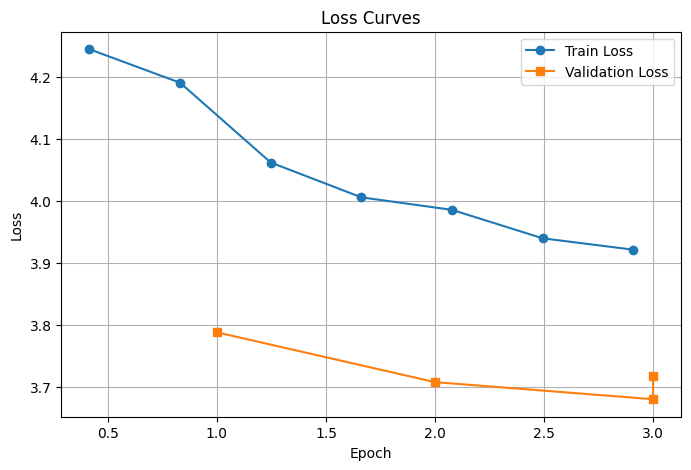

In [43]:
plt.figure(figsize=(8,5))

train_logs = history.dropna(subset=["loss"])
eval_logs = history.dropna(subset=["eval_loss"])

plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print(tokenizer.mask_token)

In [46]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model=trainer.model,
    tokenizer=tokenizer
)

result = fill_mask("The capital of France is <mask>.")

print(result)

[{'score': 0.4445136785507202, 'token': 2201, 'token_str': ' Paris', 'sequence': 'The capital of France is Paris.'}, {'score': 0.04916094243526459, 'token': 12790, 'token_str': ' Lyon', 'sequence': 'The capital of France is Lyon.'}, {'score': 0.01859116367995739, 'token': 20298, 'token_str': ' Brittany', 'sequence': 'The capital of France is Brittany.'}, {'score': 0.018001705408096313, 'token': 5459, 'token_str': ' Berlin', 'sequence': 'The capital of France is Berlin.'}, {'score': 0.01782565750181675, 'token': 928, 'token_str': ' London', 'sequence': 'The capital of France is London.'}]


### MLM

In [ ]:
model_checkpoint = "distilroberta-base"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)
tokenized_datasets = datasets.map(tokenize_function, batched=True, num_proc=4, remove_columns=["text"])

In [ ]:
lm_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    batch_size=1000,
    num_proc=4,
)

In [ ]:
from transformers import AutoModelForMaskedLM
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

In [ ]:
model_name = model_checkpoint.split("/")[-1]
training_args = TrainingArguments(
    f"{model_name}-finetuned-wikitext2",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
)

In [ ]:
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_datasets["train"],
    eval_dataset=lm_datasets["validation"],
    data_collator=data_collator,
)